# BioVision-Path
## Latent Feature Representation & Model Interpretability using Grad-CAM

### OBJECTIVE
This notebook implements deep feature representation extraction and explainable AI (XAI) overlays.
We will:
1. Extract deep embeddings from the penultimate pooling layer of the trained ResNet-18 classification model using a forward hook.
2. Reduce embedding dimensionality using PCA and t-SNE, plotting class-colored clusters.
3. Query the feature space using K-Nearest Neighbors to retrieve identical histopathology patches.
4. Implement a custom Grad-CAM class to overlay visual attribution maps for correct and incorrect test predictions.

### 1. Setup & Environment

In [1]:
# Environment Report & CUDA Detection
import sys
import torch
import torchvision
from src.reproducibility import print_environment_report, set_seed
from src.config import CONFIG

# Print report
env = print_environment_report()
set_seed(CONFIG["seed"])


                    ENVIRONMENT REPORT                    
Python Version    : 3.10.9
PyTorch Version   : 2.13.0+cpu
CUDA Available    : False
GPU Name          : None (CPU Fallback)
[Notice] CUDA is not available. System is running in CPU fallback mode.
         In GPU environments (like Colab GPU runtime), this will significantly slow training.
         Please check runtime settings if a GPU was expected.
[Reproducibility] Random seed set to: 42


### 2. Penultimate Feature Extraction

In [2]:
# Load ResNet-18 model checkpoint and dataloader
from src.models import get_resnet18_model
from src.data import get_pathmnist_dataloaders, get_pathmnist_metadata
from src.preprocessing import get_classification_transforms
import os

meta = get_pathmnist_metadata()
train_trans, val_trans = get_classification_transforms(CONFIG["classification"]["image_size"])

# Use demo loader to retrieve a small representation subset
_, _, test_loader = get_pathmnist_dataloaders(
    batch_size=CONFIG["classification"]["demo"]["batch_size"],
    size=CONFIG["classification"]["image_size"],
    train_transform=train_trans,
    val_transform=val_trans,
    test_transform=val_trans,
    demo_mode=True,
    subset_size=200
)

# Load model
model = get_resnet18_model(num_classes=meta["n_classes"], pretrained=False).to(CONFIG["device"])
chk_path = "checkpoints/resnet18_classification.pth"
if os.path.exists(chk_path):
    model.load_state_dict(torch.load(chk_path, map_location=CONFIG["device"]))
    print("ResNet-18 checkpoint loaded successfully!")
else:
    print("ResNet-18 checkpoint not found. Using current weights for test verification.")


[Data] DEMO MODE: Subsetting datasets. Train: 200, Val: 100, Test: 100


ResNet-18 checkpoint loaded successfully!


In [3]:
# Extract features
from src.feature_extraction import extract_resnet18_embeddings

embeddings, labels, images = extract_resnet18_embeddings(model, test_loader, CONFIG["device"])
print(f"Extracted embedding matrix shape: {embeddings.shape}")
print(f"Extracted labels array shape    : {labels.shape}")


Extracted embedding matrix shape: (100, 512)
Extracted labels array shape    : (100,)


### 3. Dimensionality Reduction & Nearest Neighbors

PCA components shape: (100, 2)
Explained variance ratio (first 2 components): [0.23636097 0.18898822]


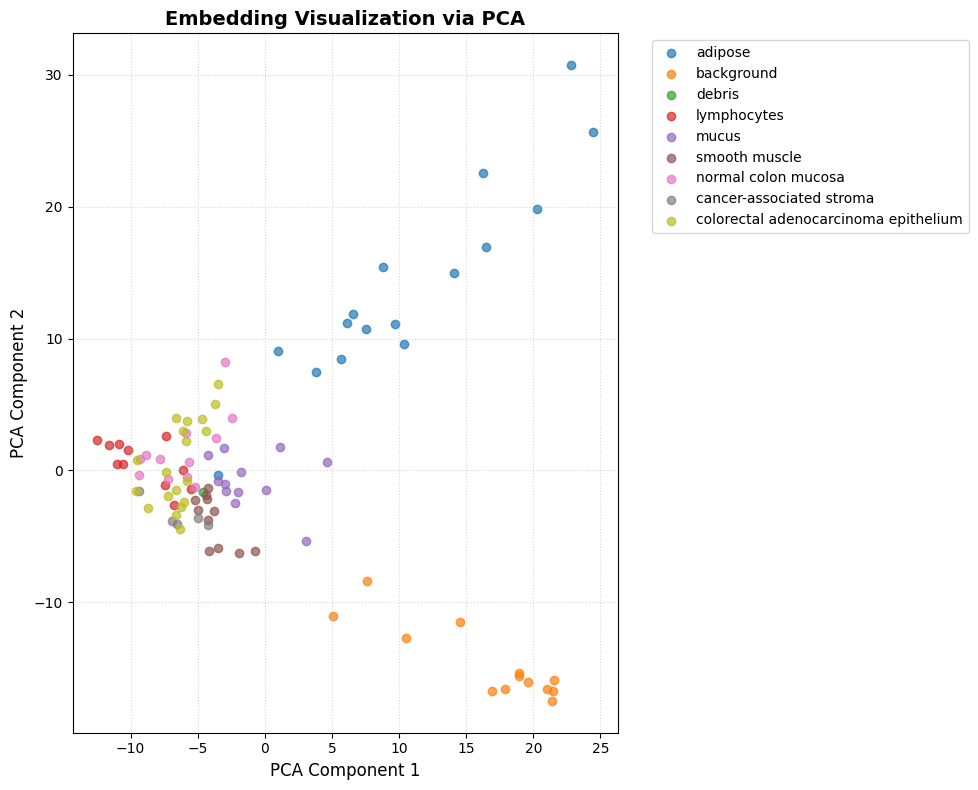

In [4]:
# Run PCA
from src.feature_extraction import run_pca_reduction
from src.visualization import plot_embeddings

pca_embs, explained_vars = run_pca_reduction(embeddings)
print(f"PCA components shape: {pca_embs.shape}")
print(f"Explained variance ratio (first 2 components): {explained_vars}")

plot_embeddings(pca_embs, labels, meta["classes"], method_name="PCA", save_path="outputs/features/pca_embeddings.png")


Query index: 10 (Class: 5)
Top 5 nearest neighbors indices: [np.int64(26), np.int64(75), np.int64(25), np.int64(39), np.int64(71)]


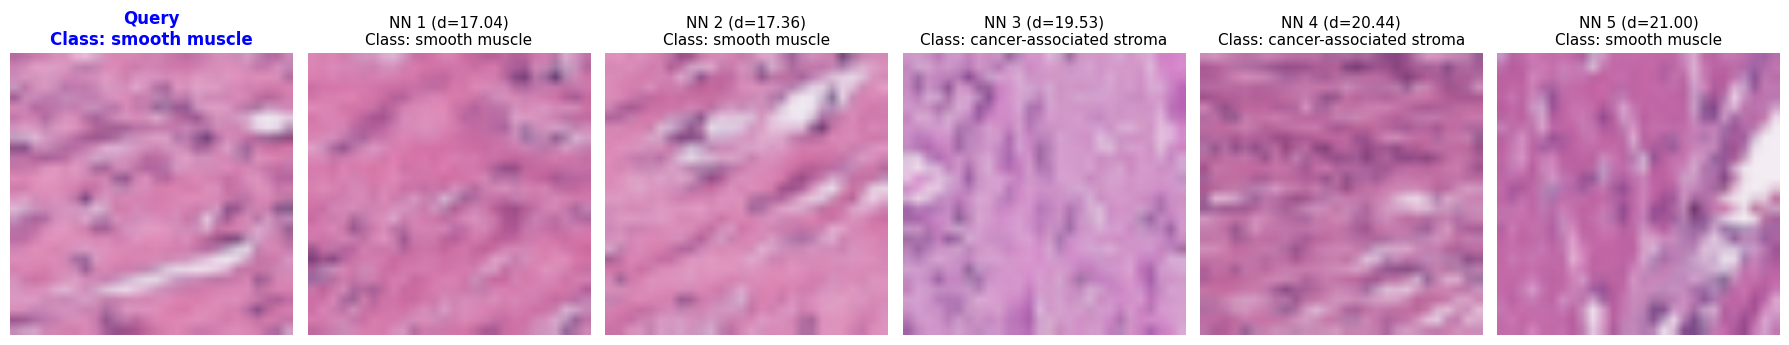

In [5]:
# Query Nearest Neighbors
from src.feature_extraction import find_nearest_neighbors
from src.visualization import plot_nearest_neighbors

query_idx = 10
neighbors, distances = find_nearest_neighbors(query_idx, embeddings, top_k=5)

print(f"Query index: {query_idx} (Class: {labels[query_idx]})")
print(f"Top 5 nearest neighbors indices: {neighbors}")

# Visualize neighbors
query_img = images[query_idx]
neighbor_imgs = [images[idx] for idx in neighbors]
neighbor_classes = [labels[idx] for idx in neighbors]

plot_nearest_neighbors(
    query_img=query_img,
    neighbor_imgs=neighbor_imgs,
    distances=distances,
    query_class=labels[query_idx],
    neighbor_classes=neighbor_classes,
    class_names=meta["classes"],
    save_path="outputs/features/nearest_neighbors.png"
)


### 4. Custom Grad-CAM Explainability

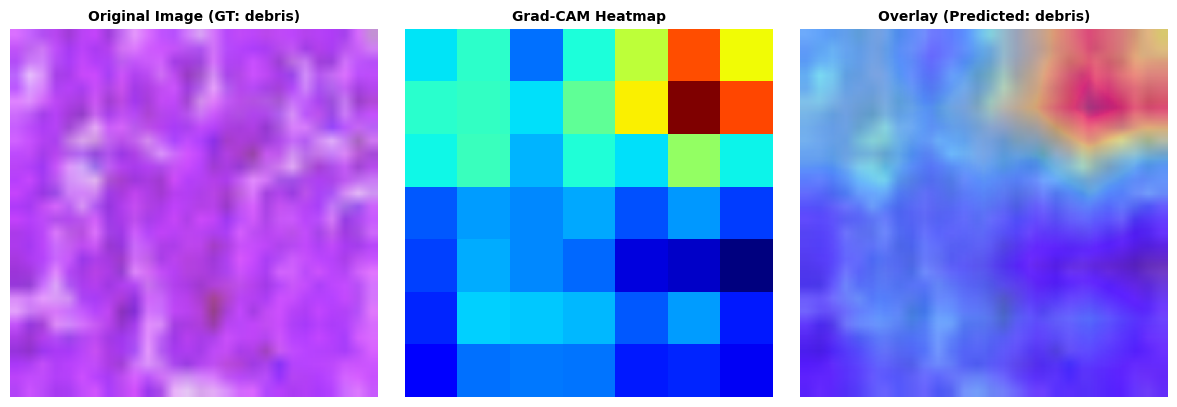

In [6]:
# Implement Grad-CAM forward-backward hooks
from src.explainability import GradCAM, overlay_gradcam_on_image

# Target model.layer4 for final feature map representation
gradcam = GradCAM(model, model.layer4)

# Load a test sample
img_tensor = torch.tensor(images[12:13]).to(CONFIG["device"]) # (1, 3, 224, 224)
heatmap, pred_class = gradcam.generate_heatmap(img_tensor)

# Generate overlay
from src.visualization import denormalize_image
original_np = denormalize_image(images[12], mean=[0.707, 0.522, 0.672], std=[0.166, 0.186, 0.158])
blended, color_heat = overlay_gradcam_on_image(original_np, heatmap, alpha=0.5)

# Plot outputs
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(original_np)
axes[0].set_title(f"Original Image (GT: {meta['classes'][str(labels[12])]})", fontsize=10, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(heatmap, cmap="jet")
axes[1].set_title("Grad-CAM Heatmap", fontsize=10, fontweight="bold")
axes[1].axis("off")

axes[2].imshow(blended)
axes[2].set_title(f"Overlay (Predicted: {meta['classes'][str(pred_class)]})", fontsize=10, fontweight="bold")
axes[2].axis("off")

plt.tight_layout()
plt.savefig("outputs/explainability/gradcam_overlay.png", bbox_inches="tight")
plt.show()

gradcam.close()


### 5. Responsible Use & XAI Limitations
- **attribution vs causality**: Grad-CAM visualizes which pixels influenced the model's logits; it does NOT establish clinical reasoning or prove that the model is looking at valid physiological biomarkers.
- **resolution limit**: Grad-CAM heatmaps are derived from low-resolution feature maps (e.g. 7x7 in ResNet-18) and upscaled, leading to coarse localization boundaries.